<!-- open-in-badges -->
[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EAFIT-IA/si7011-DeepLearning/blob/main/sessions/02_deep_training/notebooks/sesion_02_3_normalizacion_regularizacion.ipynb) [![Abrir en Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/EAFIT-IA/si7011-DeepLearning/blob/main/sessions/02_deep_training/notebooks/sesion_02_3_normalizacion_regularizacion.ipynb) [![Abrir en Lightning Studio](https://pl-bolts-doc-images.s3.us-east-2.amazonaws.com/app-2/studio-badge.svg)](https://lightning.ai/new?repo_url=https%3A%2F%2Fgithub.com%2FEAFIT-IA%2Fsi7011-DeepLearning%2Fblob%2Fmain%2Fsessions%2F02_deep_training%2Fnotebooks%2Fsesion_02_3_normalizacion_regularizacion.ipynb)

# SI7011 · Sesión 02 · 3. Normalización y regularización
**Juan David Martínez Vargas · Universidad EAFIT**

Acompaña la **Parte 4** de las diapositivas. La teoría está allá; aquí cada celda cambia **una sola cosa** y comparamos curvas.

| Sección | Lo que cambia | Qué mirar |
|---|---|---|
| 1 | MLP que sobreajusta (línea base) | la brecha entre entrenamiento y validación |
| 2 | weight decay (AdamW) | la pérdida de validación deja de subir |
| 3 | Dropout | lo mismo, por otro camino |
| 4 | early stopping | quedarse con la mejor época |
| 5 | BatchNorm en un MLP de 20 capas | de no aprender nada a aprender |
| 6 | BatchNorm: `train()` frente a `eval()` | por qué importa el modo |

LayerNorm queda para el notebook 4, junto con las conexiones residuales. Corre en CPU en 1–2 minutos (Colab, Kaggle, Lightning o local).

In [1]:
import copy, time
import matplotlib.pyplot as plt
import torch
from torch import nn
from matplotlib.ticker import MaxNLocator
from torchvision import datasets

torch.manual_seed(0)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})
int_epochs = lambda: plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
print('PyTorch', torch.__version__)

PyTorch 2.14.1+cu130


## Datos: Fashion-MNIST como vectores
Cada imagen de 28×28 se aplana en un vector de 784 valores. Usamos solo **10 000** ejemplos de entrenamiento para que el sobreajuste se vea pronto. La validación sale del resto del conjunto de entrenamiento, y el conjunto de prueba no se toca hasta el final.

In [2]:
train_set = datasets.FashionMNIST('data', train=True, download=True)
test_set = datasets.FashionMNIST('data', train=False, download=True)
CLASSES = train_set.classes

X = train_set.data.reshape(-1, 784).float() / 255
y = train_set.targets
perm = torch.randperm(len(X), generator=torch.Generator().manual_seed(0))
X_train, y_train = X[perm[:10_000]], y[perm[:10_000]]
X_val, y_val = X[perm[50_000:]], y[perm[50_000:]]
X_test, y_test = test_set.data.reshape(-1, 784).float() / 255, test_set.targets

mu, sd = X_train.mean(), X_train.std()          # estadísticas solo de entrenamiento
X_train, X_val, X_test = [(t - mu) / sd for t in (X_train, X_val, X_test)]

In [3]:
X_train.shape, X_val.shape, X_test.shape

(torch.Size([10000, 784]), torch.Size([10000, 784]), torch.Size([10000, 784]))

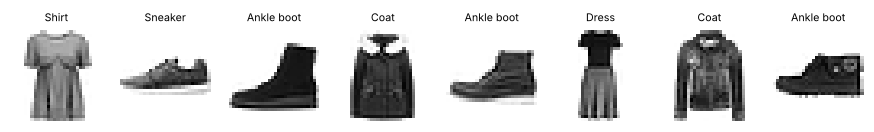

In [4]:
fig, axes = plt.subplots(1, 8, figsize=(10, 1.6))
for ax, img, lab in zip(axes, train_set.data[perm[:8]], train_set.targets[perm[:8]]):
    ax.imshow(img, cmap='gray_r'); ax.set_title(CLASSES[lab], fontsize=7); ax.axis('off')
plt.show()

## Herramientas: entrenar, evaluar y graficar
Es el mismo loop de la sesión 01. Lo único nuevo es `model.train()` y `model.eval()`: Dropout y BatchNorm se comportan distinto en cada modo (sección 6).

In [5]:
loss_fn = nn.CrossEntropyLoss()

def train_epoch(model, opt, batch_size=128):
    model.train()
    perm = torch.randperm(len(X_train))
    total = 0.0
    for i in range(0, len(X_train), batch_size):
        b = perm[i:i + batch_size]
        loss = loss_fn(model(X_train[b]), y_train[b])
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item() * len(b)
    return total / len(X_train)

@torch.no_grad()
def evaluate(model, X, y):
    model.eval()
    logits = model(X)
    return loss_fn(logits, y).item(), (logits.argmax(1) == y).float().mean().item()

In [6]:
def fit(model, opt, epochs=20):
    hist = {'loss': [], 'val_loss': [], 'val_acc': []}
    for epoch in range(epochs):
        hist['loss'].append(train_epoch(model, opt))
        val_loss, val_acc = evaluate(model, X_val, y_val)
        hist['val_loss'].append(val_loss); hist['val_acc'].append(val_acc)
    print(f"época {epochs}: loss {hist['loss'][-1]:.3f} · val_loss {val_loss:.3f} · val_acc {val_acc:.3f}")
    return hist

def plot_curves(hists, key='val_loss', title=''):
    for name, h in hists.items():
        plt.plot(range(1, len(h[key]) + 1), h[key], label=name)
    plt.xlabel('época'); plt.ylabel(key); plt.title(title); plt.legend(); int_epochs(); plt.show()

## 1. Línea base: un MLP que sobreajusta

In [7]:
torch.manual_seed(0)
model = nn.Sequential(
    nn.Linear(784, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 10),
)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
h_base = fit(model, opt)
model_base = model

época 20: loss 0.113 · val_loss 0.521 · val_acc 0.860


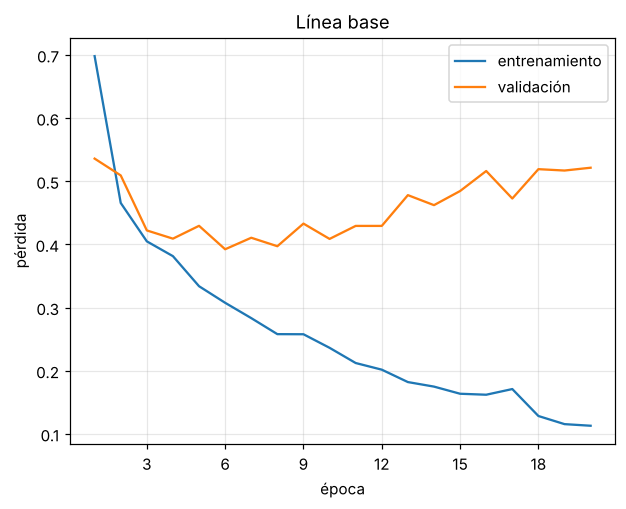

In [8]:
plt.plot(range(1, 21), h_base['loss'], label='entrenamiento')
plt.plot(range(1, 21), h_base['val_loss'], label='validación')
plt.xlabel('época'); plt.ylabel('pérdida'); plt.title('Línea base'); plt.legend(); int_epochs(); plt.show()

La pérdida de entrenamiento sigue bajando, pero la de validación toca fondo hacia la época 6 y luego **sube**. Desde ese punto el modelo memoriza los 10 000 ejemplos en lugar de aprender lo que generaliza.

## 2. Weight decay con AdamW
**Cambia una línea:** `Adam` → `AdamW(weight_decay=1.0)`. En cada paso los pesos se encogen hacia cero, desacoplado del gradiente (diapositiva *Weight decay with Adam: AdamW*).

In [9]:
torch.manual_seed(0)
model = nn.Sequential(
    nn.Linear(784, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 10),
)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1.0)
h_wd = fit(model, opt)
model_wd = model

época 20: loss 0.209 · val_loss 0.407 · val_acc 0.859


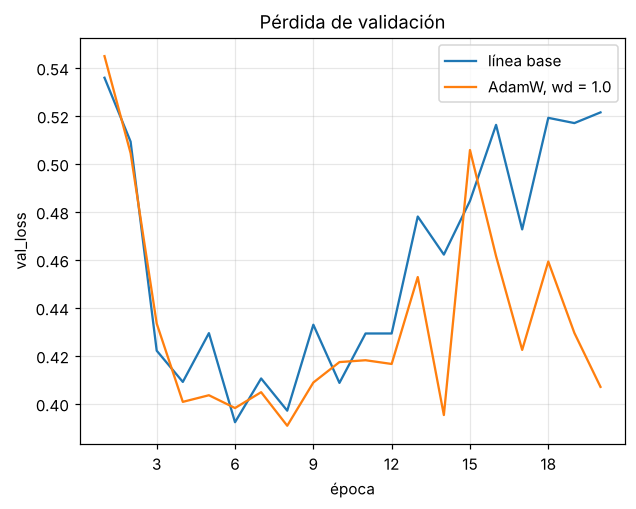

In [10]:
plot_curves({'línea base': h_base, 'AdamW, wd = 1.0': h_wd}, title='Pérdida de validación')

El efecto es más **modesto y ruidoso** que el de Dropout: la validación sube menos al final, pero las oscilaciones de Adam siguen ahí. Para ver el mecanismo hay que mirar los pesos, no solo la curva:

In [11]:
weight_norm = lambda m: sum(p.pow(2).sum() for n, p in m.named_parameters() if 'weight' in n).sqrt().item()
print(f'‖W‖ línea base: {weight_norm(model_base):.1f}')
print(f'‖W‖ AdamW, wd = 1.0: {weight_norm(model_wd):.1f}')

‖W‖ línea base: 33.4
‖W‖ AdamW, wd = 1.0: 17.8


## 3. Dropout
**Cambia la arquitectura:** un `nn.Dropout(0.5)` después de cada capa oculta. Durante el entrenamiento, cada unidad se apaga con probabilidad 0.5, y en `eval()` todas quedan activas.

In [12]:
torch.manual_seed(0)
model = nn.Sequential(
    nn.Linear(784, 512), nn.ReLU(), nn.Dropout(0.5),
    nn.Linear(512, 512), nn.ReLU(), nn.Dropout(0.5),
    nn.Linear(512, 10),
)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
h_drop = fit(model, opt)

época 20: loss 0.303 · val_loss 0.396 · val_acc 0.859


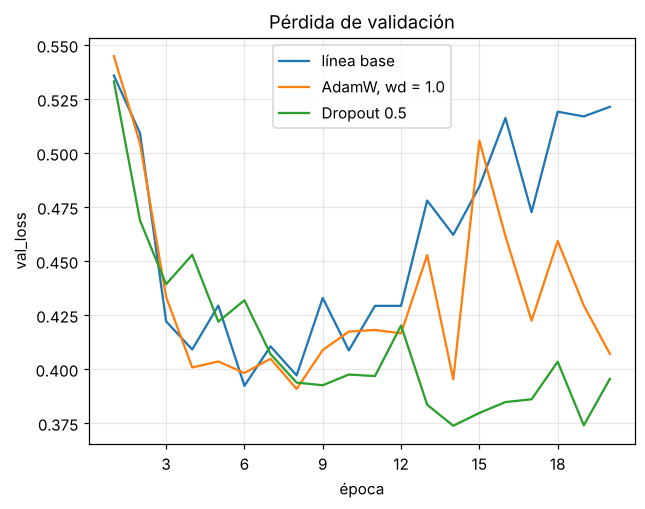

In [13]:
plot_curves({'línea base': h_base, 'AdamW, wd = 1.0': h_wd, 'Dropout 0.5': h_drop}, title='Pérdida de validación')

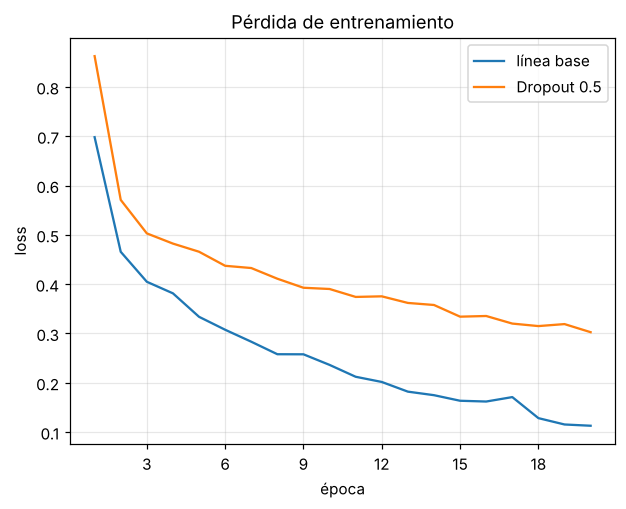

In [14]:
plot_curves({'línea base': h_base, 'Dropout 0.5': h_drop}, key='loss', title='Pérdida de entrenamiento')

Con Dropout, la pérdida de **entrenamiento** queda más alta: el modelo tiene más difícil memorizar. Ese es justamente el efecto que buscamos.

## 4. Early stopping
**Cambia el loop:** después de cada época se mira `val_loss`. Se guarda una copia del mejor estado y se para cuando pasan `patience` épocas sin mejorar.

In [15]:
torch.manual_seed(0)
model = nn.Sequential(
    nn.Linear(784, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 10),
)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

patience, best_loss, best_state, bad_epochs = 3, float('inf'), None, 0
for epoch in range(1, 21):
    train_epoch(model, opt)
    val_loss, val_acc = evaluate(model, X_val, y_val)
    if val_loss < best_loss:
        best_loss, best_epoch, best_state, bad_epochs = val_loss, epoch, copy.deepcopy(model.state_dict()), 0
    else:
        bad_epochs += 1
    print(f'época {epoch:2d} · val_loss {val_loss:.3f}' + ('  ← mejor' if bad_epochs == 0 else ''))
    if bad_epochs == patience:
        print(f'Se detiene en la época {epoch}; se recupera la época {best_epoch}.')
        break

model.load_state_dict(best_state)
model_es = model
evaluate(model_es, X_val, y_val)

época  1 · val_loss 0.536  ← mejor


época  2 · val_loss 0.509  ← mejor


época  3 · val_loss 0.422  ← mejor


época  4 · val_loss 0.409  ← mejor


época  5 · val_loss 0.429


época  6 · val_loss 0.392  ← mejor


época  7 · val_loss 0.411


época  8 · val_loss 0.397


época  9 · val_loss 0.433
Se detiene en la época 9; se recupera la época 6.


(0.39232349395751953, 0.8561000227928162)

El modelo final no es el de la última época, sino `best_state`. Por eso hay que guardar una **copia** (`deepcopy`): `state_dict()` devuelve referencias a los mismos tensores, que el optimizador sigue modificando.

## 5. BatchNorm en un MLP profundo
Cambiamos de problema. El objetivo ya no es generalizar, sino **optimizar**: ¿se puede entrenar un MLP de **20 capas** con la inicialización por defecto y SGD con momentum?

In [16]:
def deep_mlp(norm=None, depth=20, width=128):
    layers, n_in = [], 784
    for _ in range(depth):
        layers += [nn.Linear(n_in, width)] + ([norm(width)] if norm else []) + [nn.ReLU()]
        n_in = width
    return nn.Sequential(*layers, nn.Linear(width, 10))

deep_mlp()[:6]

Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=128, bias=True)
  (5): ReLU()
)

In [17]:
torch.manual_seed(0)
model = deep_mlp()
opt = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
h_deep = fit(model, opt, epochs=15)

época 15: loss 2.303 · val_loss 2.303 · val_acc 0.102


In [18]:
import math
math.log(10)

2.302585092994046

La pérdida queda en $\ln 10 \approx 2.303$, que es la de adivinar al azar entre 10 clases. La señal se desvanece a través de las 20 capas (notebook 1) y el gradiente no llega a las primeras capas.

**Cambia un argumento:** `deep_mlp(norm=nn.BatchNorm1d)` agrega una capa de BatchNorm después de cada `Linear`.

In [19]:
torch.manual_seed(0)
model = deep_mlp(norm=nn.BatchNorm1d)
opt = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
h_bn = fit(model, opt, epochs=15)
model_bn = model

época 15: loss 0.403 · val_loss 0.439 · val_acc 0.839


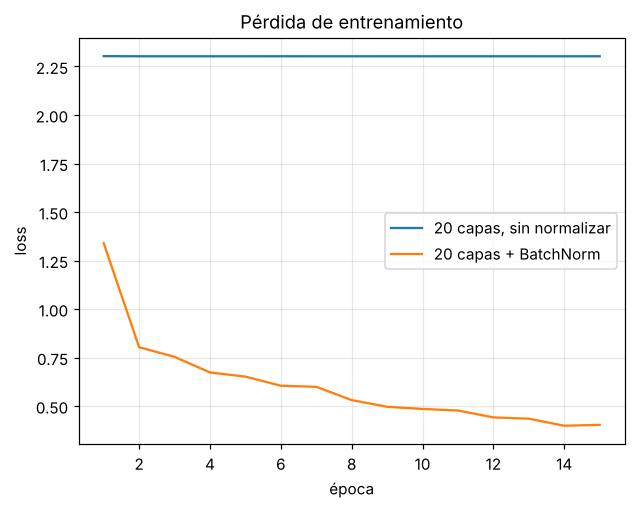

In [20]:
plot_curves({'20 capas, sin normalizar': h_deep, '20 capas + BatchNorm': h_bn}, key='loss', title='Pérdida de entrenamiento')

## 6. BatchNorm: `train()` frente a `eval()`
En `train()`, BatchNorm normaliza con la media y la varianza **del lote**. En `eval()`, usa promedios móviles que acumuló durante el entrenamiento. Con un solo ejemplo no existe la varianza del lote:

In [21]:
x1 = X_val[:1]
model_bn.train()
try:
    model_bn(x1)
except ValueError as e:
    print('train():', e)

train(): Expected more than 1 value per channel when training, got input size torch.Size([1, 128])


In [22]:
model_bn.eval()
with torch.no_grad():
    print('eval(): predicción =', CLASSES[model_bn(x1).argmax().item()], '· real =', CLASSES[y_val[0].item()])

eval(): predicción = Bag · real = Bag


In [23]:
bn = model_bn[1]
bn.running_mean[:5], bn.running_var[:5]

(tensor([ 3.2067, -0.7870,  2.9891, -4.5563, -2.8043]),
 tensor([53.6371, 18.2971, 64.7488, 41.6955, 20.7541]))

Estos promedios forman parte del modelo: se guardan en `state_dict()` y viajan con él al despliegue. Si se te olvida `model.eval()` antes de predecir, cada predicción depende de qué otros ejemplos venían en el mismo lote.

LayerNorm evita esa dependencia porque normaliza cada ejemplo sobre sus propias unidades. La usaremos en el notebook 4, con residuales, y en los Transformers (sesión 05).

## Resumen y evaluación en prueba

In [24]:
runs = {'línea base': h_base, 'AdamW, wd = 1.0': h_wd, 'Dropout 0.5': h_drop}
for name, h in runs.items():
    i = min(range(len(h['val_loss'])), key=h['val_loss'].__getitem__)
    print(f"{name:16s} mejor val_loss {h['val_loss'][i]:.3f} (época {i + 1:2d}) · val_loss final {h['val_loss'][-1]:.3f} · val_acc final {h['val_acc'][-1]:.3f}")

línea base       mejor val_loss 0.392 (época  6) · val_loss final 0.521 · val_acc final 0.860
AdamW, wd = 1.0  mejor val_loss 0.391 (época  8) · val_loss final 0.407 · val_acc final 0.859
Dropout 0.5      mejor val_loss 0.374 (época 14) · val_loss final 0.396 · val_acc final 0.859


La prueba se evalúa **una sola vez**, con el modelo que se eligió mirando la validación. Si se consulta la prueba para decidir, deja de ser una estimación honesta.

In [25]:
test_loss, test_acc = evaluate(model_es, X_test, y_test)
print(f'early stopping · prueba: loss {test_loss:.3f} · acc {test_acc:.3f}')

early stopping · prueba: loss 0.432 · acc 0.847


## Tu turno · 10 minutos
Copia la celda de la sección que corresponda, cambia **una** cosa y superpón la curva nueva con `plot_curves`.

1. Combina Dropout 0.3 con `AdamW(weight_decay=1.0)`. ¿Se suman los efectos, o uno ya hace el trabajo del otro?
2. Repite la línea base con 50 000 ejemplos de entrenamiento (`perm[:50_000]`). ¿Qué le pasa a la brecha? ¿Siguen haciendo falta Dropout y weight decay?
3. En la sección 5, sube `lr` a 0.05. ¿Sigue entrenando el modelo con BatchNorm? ¿Y el que no tiene normalización?
4. Pon BatchNorm **después** de la ReLU en lugar de antes. ¿Cambia algo?
5. En la sección 4, usa `patience = 1` y luego `patience = 8`. ¿Qué época recuperas en cada caso?

**Para pensar.** Dropout y weight decay atacan el sobreajuste, mientras que BatchNorm atacó un problema de optimización. ¿Cuál de las dos curvas, entrenamiento o validación, miraste en cada caso para saberlo?

In [26]:
# Experimento 1: Dropout 0.3 + AdamW(weight_decay=1.0)


### Referencias
- Ioffe y Szegedy (2015), *Batch Normalization*, ICML.
- Srivastava et al. (2014), *Dropout*, JMLR · Loshchilov y Hutter (2019), *Decoupled Weight Decay Regularization*, ICLR.
- Chollet y Watson (2025), *Deep Learning with Python*, 3.ª ed., cap. 5 (el formato de comparar una sola variable a la vez viene de ahí).